# 02 — Preprocessing one customer sub-sensor

Only Sensor A, sub-sensor 0 is loaded and shown. Every array keeps a sensor dimension of length one
because the CNN expects it, but no other sub-sensor enters preprocessing, training, or a figure.

In [1]:
from pathlib import Path
import sys
HERE=Path.cwd()
if not (HERE/'day3_utils.py').exists(): HERE=HERE/'Evaluation Seminar'/'Day_03'
ROOT=HERE.parents[1]
sys.path.insert(0,str(HERE)); sys.path.insert(0,str(ROOT/'Networks'))

import numpy as np
import matplotlib.pyplot as plt
from day3_utils import load_single_subsensor_splits,fit_input_zscore,apply_zscore,fit_target_zscore
splits=load_single_subsensor_splits('acetone')
print({name:value['X'].shape for name,value in splits.items()})

{'train': (1090, 1, 1440, 1), 'val': (274, 1, 1440, 1), 'test': (338, 1, 1440, 1), 'test_extra': (1392, 1, 1440, 1)}


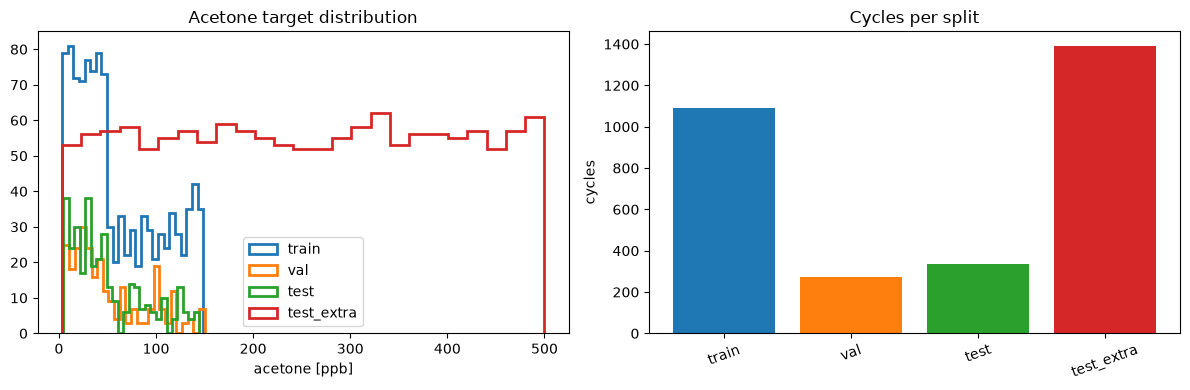

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {
    "train": "tab:blue",
    "val": "tab:orange",
    "test": "tab:green",
    "test_extra": "tab:red",
}
for split_name, split in splits.items():
    axes[0].hist(
        split["y"],
        bins=25,
        histtype="step",
        linewidth=2,
        label=split_name,
        color=colors[split_name],
    )
axes[0].set(title="Acetone target distribution", xlabel="acetone [ppb]")
axes[0].legend()

split_sizes = [len(splits[name]["X"]) for name in splits]
axes[1].bar(splits.keys(), split_sizes, color=colors.values())
axes[1].set(title="Cycles per split", ylabel="cycles")
axes[1].tick_params(axis="x", rotation=20)
fig.tight_layout()

## Input Z-score

For the single sub-sensor, `z = (x - mean) / std`. Mean and standard deviation are learned from
training samples and time points, then reused unchanged for validation and both test splits.
This preserves temporal structure while keeping optimization numerically stable.

In [3]:
# Fit once on training inputs, then reuse on every split.
x_mean,x_std=fit_input_zscore(splits['train']['X'])
for name,split in splits.items(): split['X_z']=apply_zscore(split['X'],x_mean,x_std)
print('stored mean/std shapes:',x_mean.shape,x_std.shape)
print('scaled training mean/std:',splits['train']['X_z'].mean(axis=(0,2),dtype=np.float64).ravel(),splits['train']['X_z'].std(axis=(0,2),dtype=np.float64).ravel())

stored mean/std shapes: (1, 1, 1, 1) (1, 1, 1, 1)
scaled training mean/std: [-3.7911462e-08] [1.00000006]


## Optional output Z-score

Targets can span a large range. Standardizing the target makes MSE gradients easier to handle.
Always invert the transformation for ppb metrics and store both target statistics with the model.

In [4]:
y_mean,y_std=fit_target_zscore(splits['train']['y'])
for split in splits.values(): split['y_z']=(split['y']-y_mean)/y_std
print('target mean/std:',y_mean,y_std)
print('inverse-transform check:',splits['val']['y_z'][0]*y_std+y_mean,splits['val']['y'][0])

target mean/std: 59.80529022216797 43.645469665527344
inverse-transform check: 32.716 32.716


## Inspect the customer's single sub-sensor

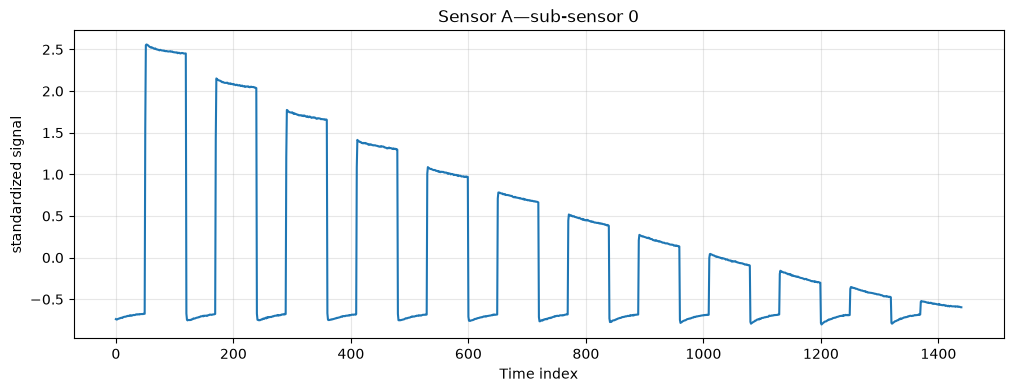

In [5]:
SUBSENSOR_INDEX = 0
sample=splits['train']['X_z'][0,SUBSENSOR_INDEX,:,0]
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(sample)
ax.set(xlabel='Time index',ylabel='standardized signal',title=f'Sensor A—sub-sensor {SUBSENSOR_INDEX}')
ax.grid(True,alpha=.3)
plt.show()


## The same sub-sensor before and after scaling

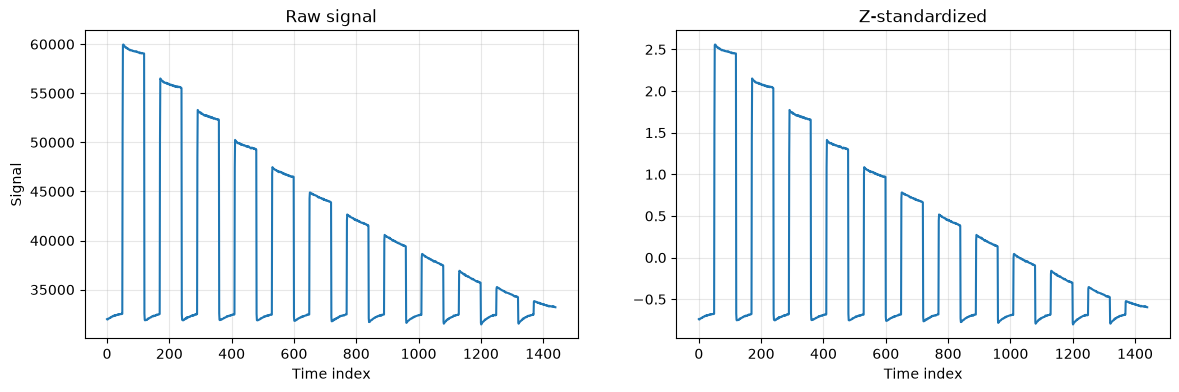

In [6]:
fig,axes=plt.subplots(1,2,figsize=(14,4),sharex=True)
for ax,key,title in zip(axes,['X','X_z'],['Raw signal','Z-standardized']):
    ax.plot(splits['train'][key][0,SUBSENSOR_INDEX,:,0])
    ax.set(title=title,xlabel='Time index'); ax.grid(True,alpha=.3)
axes[0].set_ylabel('Signal')
plt.show()


## Value distribution and temporal structure

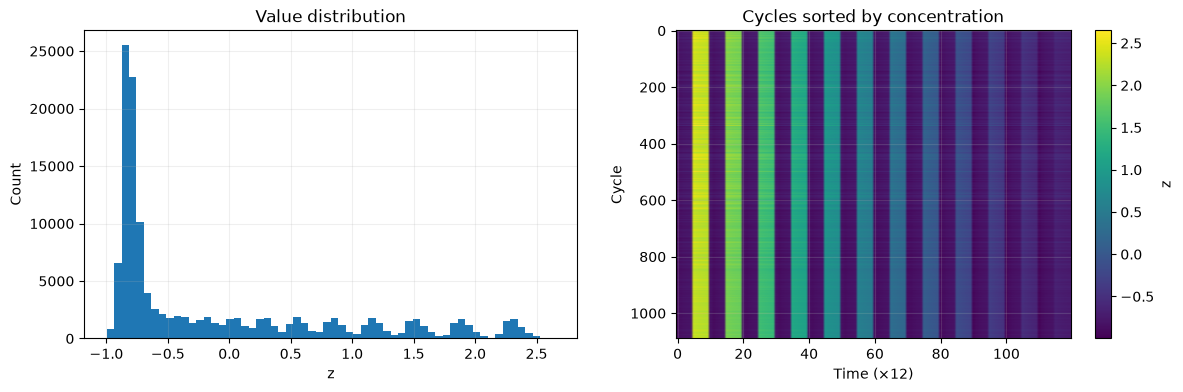

In [7]:
fig,axes=plt.subplots(1,2,figsize=(14,4))
values=splits['train']['X_z'][:,SUBSENSOR_INDEX,::12,0]
axes[0].hist(values.ravel(),bins=60); axes[0].set(title='Value distribution',xlabel='z',ylabel='Count')
order=np.argsort(splits['train']['y'])
im=axes[1].imshow(splits['train']['X_z'][order,SUBSENSOR_INDEX,::12,0],aspect='auto',cmap='viridis')
axes[1].set(title='Cycles sorted by concentration',xlabel='Time (×12)',ylabel='Cycle')
fig.colorbar(im,ax=axes[1],label='z')
for ax in axes: ax.grid(True,alpha=.2)
plt.show()
